# Nearest Neighbors Classification


Adapted by <alberto.suarez@uam.es>

from
Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.

https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html#sphx-glr-auto-examples-neighbors-plot-classification-py

Version: Final

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets

# Plotting utilities
import utilities.plot_utilities as pltu

`K vecinos más próximos` mira los k vecinos más próximos del punto que se quiere estimar y se le asigna la etiqueta por voto por mayoría.

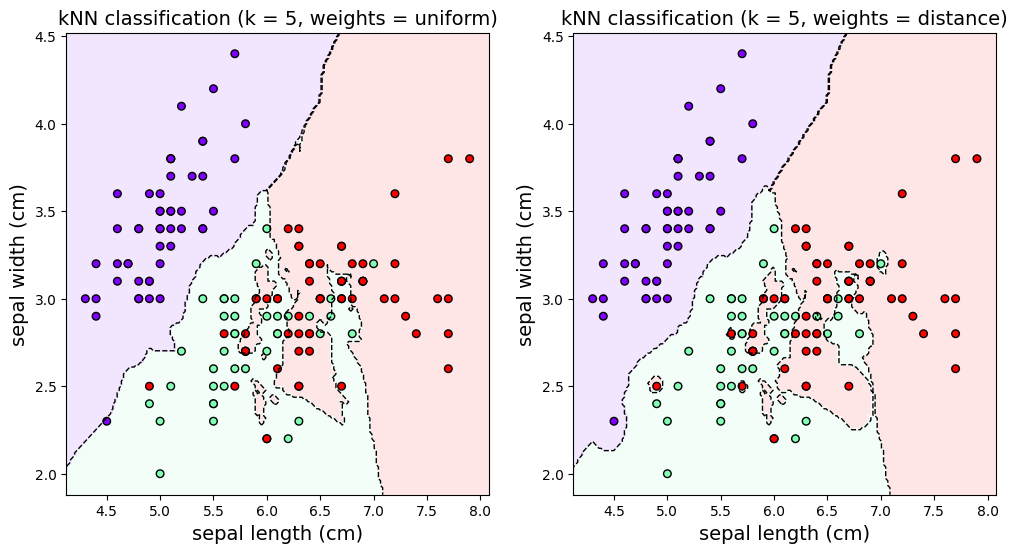

In [ ]:
# Import a dataset.
dataset = datasets.load_iris()

# Consider only two features. 
indices_features = [0, 1]
X = dataset.data[:, indices_features]
y = dataset.target

n_classes = np.unique(y) # important not using magic numbers 

# Number of neighbors for kNN (k nearest neighbors).
n_neighbors = 5

nfig = 0
fontsize = 14    


fig, axs = plt.subplots(1,2, figsize=(12, 6))

for ax, weights in zip(axs, ['uniform', 'distance']): # en general se usan uniform. El parámetro importante es n_neighbors
        
    # Create an instance of a Neighbours Classifier
    # creamos un objeto de la clase KNeighborsClassifier
    classifier = neighbors.KNeighborsClassifier(n_neighbors, # n_neighbors es un hiperparámetro
                                                weights=weights)
    
    # Train the classifier using the data
    classifier.fit(X, y)
    
    # Plot the decision regions

    decision_function = classifier.predict 
   #  decision_function = classifier.predict_proba 

    pltu.plot_2D_decision_regions(X, y, 
                                  ax=ax,
                                  decision_function=decision_function,
                                  decision_levels='auto',
                                  cmap=plt.cm.rainbow) 
    
    ax.set_title('kNN classification (k = {}, weights = {})'.format(n_neighbors, weights), 
                 fontsize=fontsize)
    
    ax.set_xlabel(dataset.feature_names[indices_features[0]], 
              fontsize=fontsize)
    ax.set_ylabel(dataset.feature_names[indices_features[1]], 
              fontsize=fontsize)

---

## Exercises

1. Compare the results using different numbers of neighbors: [1, 7, 21, 101]
2. Compare the results using different $L_p$ (*Minkowski*) distances with p = [1, 2, np.inf]

### Exercise 1.

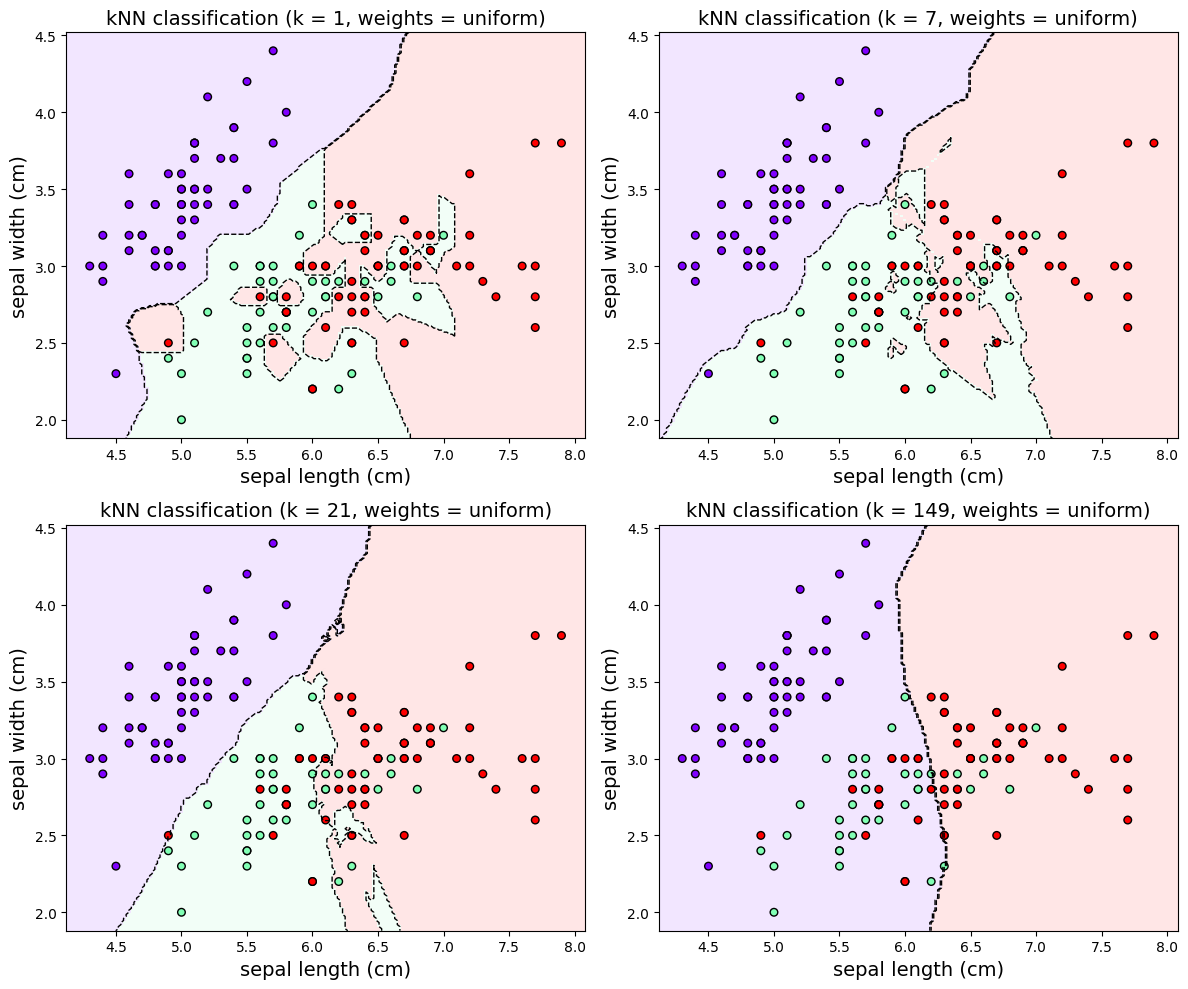

In [19]:
list_n_neighbors = [1, 7, 21, 149]
weights = 'uniform'

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for ax, neighbor in zip(axs, list_n_neighbors):
    # Create an instance of a Neighbours Classifier
    # creamos un objeto de la clase KNeighborsClassifier
    classifier = neighbors.KNeighborsClassifier(neighbor, # n_neighbors es un hiperparametro
                                                weights=weights)
    
    # Train the classifier using the data
    classifier.fit(X, y)
    
    # Plot the decision regions
    decision_function = classifier.predict
    # decision_function = classifier.predict_proba

    pltu.plot_2D_decision_regions(X, y, 
                                ax=ax,
                                decision_function=decision_function,
                                decision_levels='auto',
                                cmap=plt.cm.rainbow) 
            
    ax.set_title('kNN classification (k = {}, weights = {})'.format(neighbor, weights), 
                fontsize=fontsize)
    
    ax.set_xlabel(dataset.feature_names[indices_features[0]], 
            fontsize=fontsize)
    ax.set_ylabel(dataset.feature_names[indices_features[1]], 
            fontsize=fontsize)

fig.tight_layout()



- `k` muy grande (en este caso `k`=149) tiende a ignorar la información de la x

- la complejidad del clasificador a medida que `k` aumenta, disminuye

- la distancia no depende del centrado pero sí del escalado

### Exercise 2:

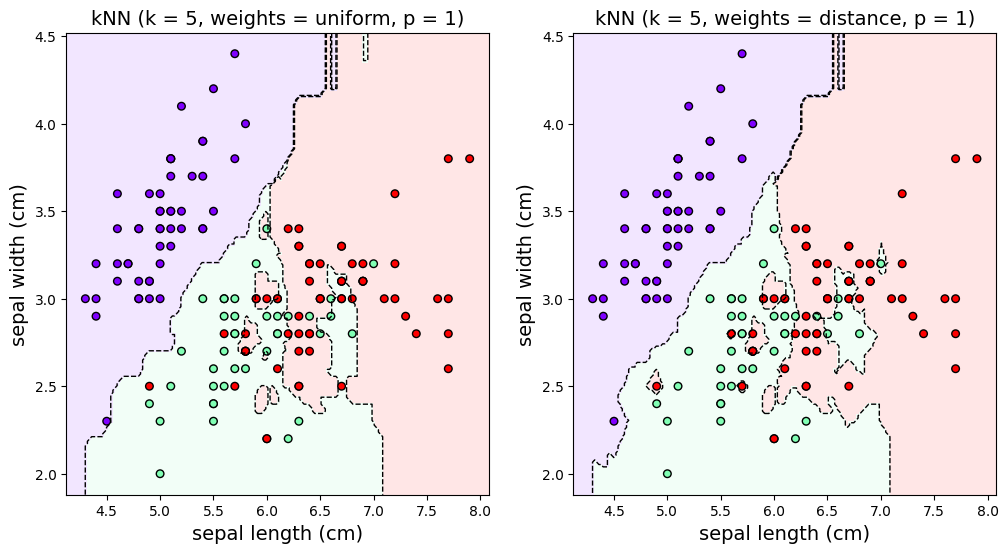

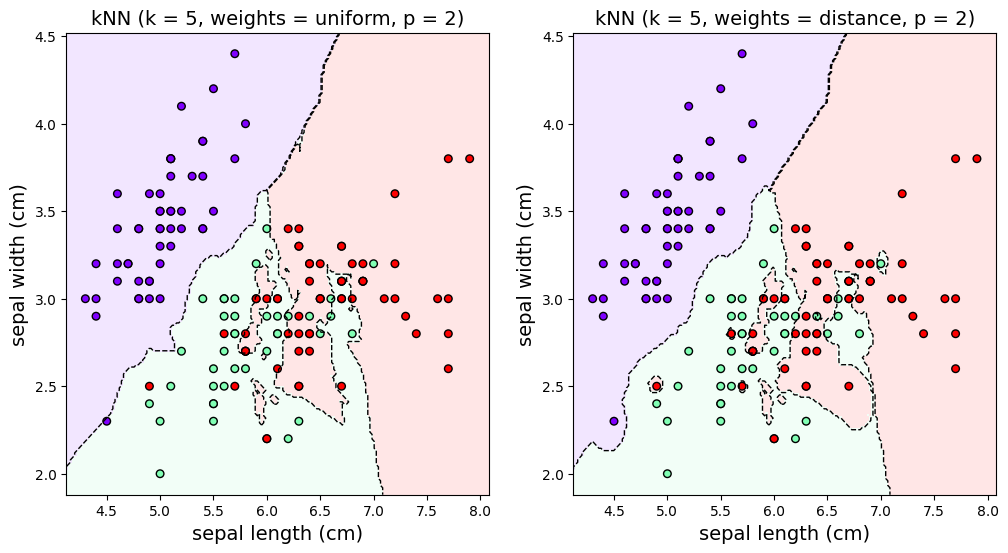

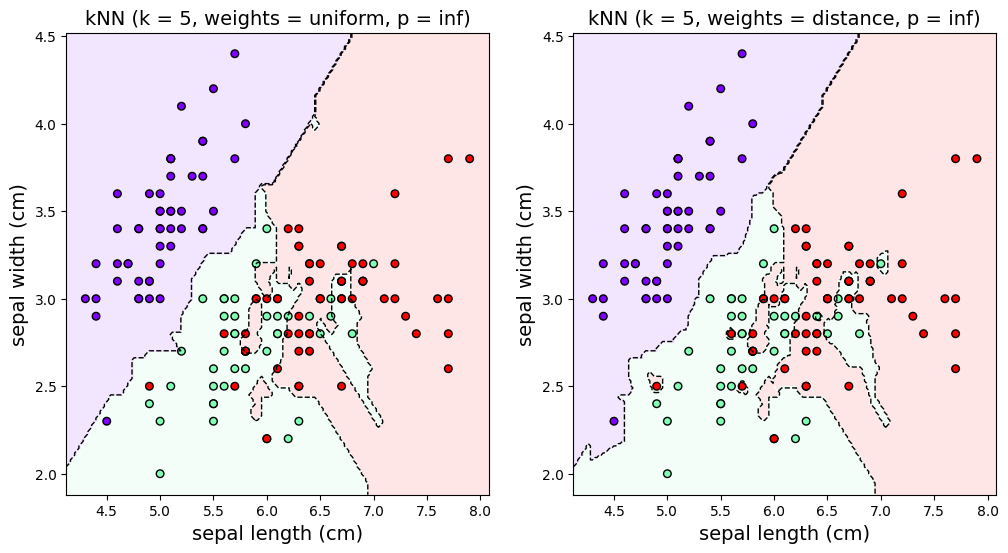

In [16]:
p_list = [1, 2, np.inf]

for p in p_list:

        fig, axs = plt.subplots(1,2, figsize=(12, 6))

        for ax, weights in zip(axs, ['uniform', 'distance']): # en general se usan uniform. El parámetro importante es n_neighbors
                
                # Create an instance of a Neighbours Classifier
                # creamos un objeto de la clase KNeighborsClassifier
                classifier = neighbors.KNeighborsClassifier(n_neighbors, # n_neighbors es un hiperparámetro
                                                                weights=weights,
                                                                p=p)
                
                # Train the classifier using the data
                classifier.fit(X, y)
                
                # Plot the decision regions

                decision_function = classifier.predict 
                #  decision_function = classifier.predict_proba 

                pltu.plot_2D_decision_regions(X, y, 
                                                ax=ax,
                                                decision_function=decision_function,
                                                decision_levels='auto',
                                                cmap=plt.cm.rainbow) 
                
                ax.set_title('kNN (k = {}, weights = {}, p = {})'.format(n_neighbors, weights, p), 
                                fontsize=fontsize)
                
                ax.set_xlabel(dataset.feature_names[indices_features[0]], 
                        fontsize=fontsize)
                ax.set_ylabel(dataset.feature_names[indices_features[1]], 
                        fontsize=fontsize)

## To explore:
https://scikit-learn.org/stable/modules/neighbors.html#